# Analisis Time Series - Peramalan Harga Telur Semarang (ARIMA/SARIMA)

**Tahapan:**
1. Import & eksplorasi data (EDA)
2. **Split data train-test** , sebelum semua tahap identifikasi model
3. Uji stasioneritas (ADF Test) → dilakukan pada data **train**
4. Analisis komponen musiman (decomposition + uji formal) → dilakukan pada data **train**
5. Differencing (jika data belum stasioner) → dilakukan pada data **train**
6. Identifikasi order (p, d, q) via ACF/PACF & `auto_arima` (termasuk versi musiman/SARIMA) → dilakukan pada data **train**
7. Estimasi/fit model ARIMA/SARIMA pada data train
8. Evaluasi model pada data test (MAE, RMSE, MAPE)
9. Diagnostik residual model
10. Forecast/peramalan periode ke depan (refit pakai seluruh data)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline

## 1. Import & Eksplorasi Data (EDA)

In [ ]:
import pandas as pd
import os

# Coba deteksi apakah dijalankan di Google Colab atau tidak
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

FILE_PATH = "/content/harga_telur_semarang.xlsx"

if IN_COLAB:
    # Upload file Excel secara interaktif di Colab
    uploaded = files.upload()
    # Ambil nama file yang benar-benar diupload (jaga-jaga kalau namanya beda)
    FILE_PATH = list(uploaded.keys())[0]
else:
    # Jalan di luar Colab (mis. Jupyter lokal) -> sesuaikan path file di bawah ini
    if not os.path.exists(FILE_PATH):
        FILE_PATH = "harga_telur_semarang.xlsx"  # cari di folder kerja saat ini

# Membaca file
df = pd.read_excel(FILE_PATH)

# Membersihkan nama kolom
df.columns = df.columns.str.strip().str.lower()

# Mengubah kolom periode menjadi format tanggal
df["periode"] = pd.to_datetime(df["periode"])

# Mengurutkan data berdasarkan periode
df = df.sort_values("periode").reset_index(drop=True)

# Menjadikan periode sebagai index
df = df.set_index("periode")

# Mengubah frekuensi data menjadi harian
df = df.asfreq("D")

# Interpolasi data yang hilang
df["semarang"] = df["semarang"].interpolate()

# Menampilkan jumlah observasi
print("Jumlah observasi:", len(df))

# Menampilkan statistik deskriptif
df.describe()

Saving harga_telur_semarang.xlsx to harga_telur_semarang.xlsx
Jumlah observasi: 364


,semarang
count,364.000000
mean,27998.644626
std,1909.367633
min,23572.071940
25%,26700.000000
50%,27550.000000
75%,29800.000000
max,31800.000000


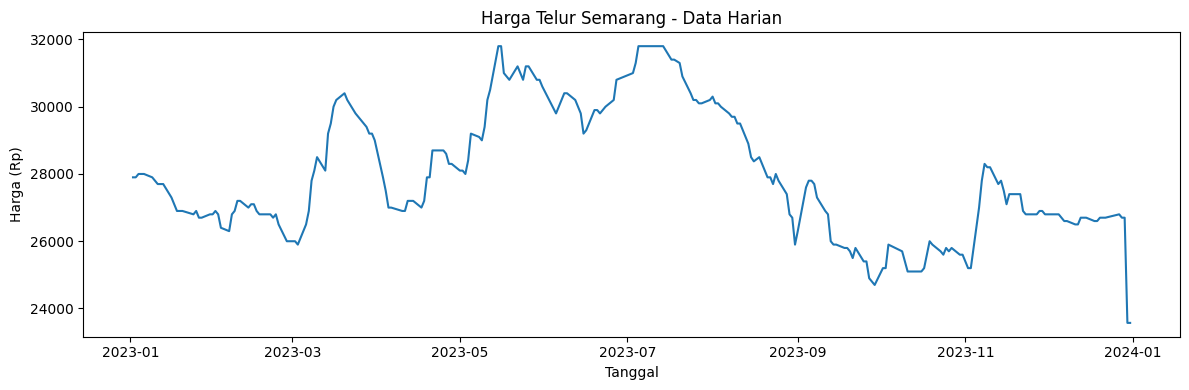

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["semarang"])
plt.title("Harga Telur Semarang - Data Harian")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.tight_layout()
plt.show()

## 2. Split Data Train-Test

Time series **tidak boleh** displit acak (random) seperti data biasa. Split harus berurutan berdasarkan waktu: data lama untuk train, data paling akhir untuk test.

Sesuai **prinsip Analisis Deret Waktu (ADW)**, split ini dilakukan **di awal**, sebelum tahap uji stasioneritas, analisis musiman, differencing, maupun identifikasi order (ACF/PACF & `auto_arima`). Dengan begitu:
- Data test benar-benar mensimulasikan "masa depan" yang belum pernah dilihat model.
- Tidak terjadi **data leakage**, yaitu bocornya informasi dari data test ke proses pemilihan/pembentukan model (mis. lewat `auto_arima` yang dijalankan pada seluruh data).
- Akurasi model yang diukur di tahap 8 benar-benar mencerminkan kemampuan generalisasi model, bukan hasil yang terlalu optimis karena model "mengintip" data uji.


In [ ]:
n_test = 14   # 14 hari terakhir dipakai sebagai data uji, sisanya untuk data latih
train = df["semarang"].iloc[:-n_test]
test = df["semarang"].iloc[-n_test:]

print(f"Jumlah data train : {len(train)}")
print(f"Jumlah data test   : {len(test)}")


Jumlah data train : 350
Jumlah data test   : 14


## 3. Uji Stasioneritas (Augmented Dickey-Fuller Test) — pada Data Train

In [ ]:
def uji_adf(series, judul="Series"):
    hasil = adfuller(series.dropna())
    print(f"\n--- ADF Test: {judul} ---")
    print("ADF Statistic :", hasil[0])
    print("p-value       :", hasil[1])
    if hasil[1] <= 0.05:
        print("=> Data STASIONER (tolak H0)")
    else:
        print("=> Data TIDAK STASIONER (gagal tolak H0)")
    return hasil[1]

# Diuji pada data TRAIN saja, bukan seluruh df, supaya data test tidak ikut
# memengaruhi keputusan (d) yang nantinya dipakai untuk membangun model.
p_value_awal = uji_adf(train, "Data Train (Asli)")



--- ADF Test: Data Train (Asli) ---
ADF Statistic : -1.9804004299630116
p-value       : 0.295232391045543
=> Data TIDAK STASIONER (gagal tolak H0)


/tmp/ipykernel_1853/1262130798.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  hasil = adfuller(series.dropna())


## 4. Analisis Komponen Musiman (Seasonal Decomposition) — pada Data Train

Bagian ini yang ditambahkan untuk menjawab pertanyaan **"apakah ada komponen musiman?"**

Karena data berupa harga harian, periodisitas musiman yang paling masuk akal untuk dicek adalah:
- **Mingguan (period=7)** → pola hari pasar / hari kerja vs akhir pekan
- **Bulanan (period=30)** → pola menjelang gajian/awal bulan atau hari besar

Kita cek keduanya dengan `seasonal_decompose` (klasik) dan `STL` (lebih robust untuk data harga yang naik-turun tajam), lalu dihitung **kekuatan musiman (seasonal strength)** secara numerik supaya tidak hanya menebak dari plot.

Seluruh analisis pada bagian ini dijalankan pada data **train** saja (bukan `df` penuh), mengikuti prinsip ADW agar data test tetap "tersembunyi" sampai tahap evaluasi.

In [ ]:
def seasonal_strength(result):
    """
    Menghitung kekuatan komponen musiman (0 = tidak ada pola musiman,
    mendekati 1 = pola musiman sangat kuat), mengikuti formula
    Hyndman & Athanasopoulos.
    """
    resid = result.resid.dropna()
    seasonal = result.seasonal.loc[resid.index]
    var_resid = np.var(resid)
    var_seasonal_resid = np.var(seasonal + resid)
    if var_seasonal_resid == 0:
        return 0.0
    return max(0, 1 - (var_resid / var_seasonal_resid))

periode_dicek = {"Mingguan (period=7)": 7, "Bulanan (period=30)": 30}

print("=== Ringkasan Kekuatan Musiman (STL, dihitung pada Data Train) ===")
for nama, period in periode_dicek.items():
    if len(train.dropna()) < 2 * period:
        print(f"{nama:<25}: data terlalu pendek untuk period={period}, dilewati")
        continue
    stl_result = STL(train, period=period, robust=True).fit()
    kekuatan = seasonal_strength(stl_result)
    keterangan = "ADA indikasi musiman" if kekuatan > 0.3 else "musiman lemah/tidak terlihat"
    print(f"{nama:<25}: kekuatan = {kekuatan:.3f}  -> {keterangan}")


=== Ringkasan Kekuatan Musiman (STL, dihitung pada Data Train) ===
Mingguan (period=7)      : kekuatan = 0.000  -> musiman lemah/tidak terlihat
Bulanan (period=30)      : kekuatan = 0.000  -> musiman lemah/tidak terlihat


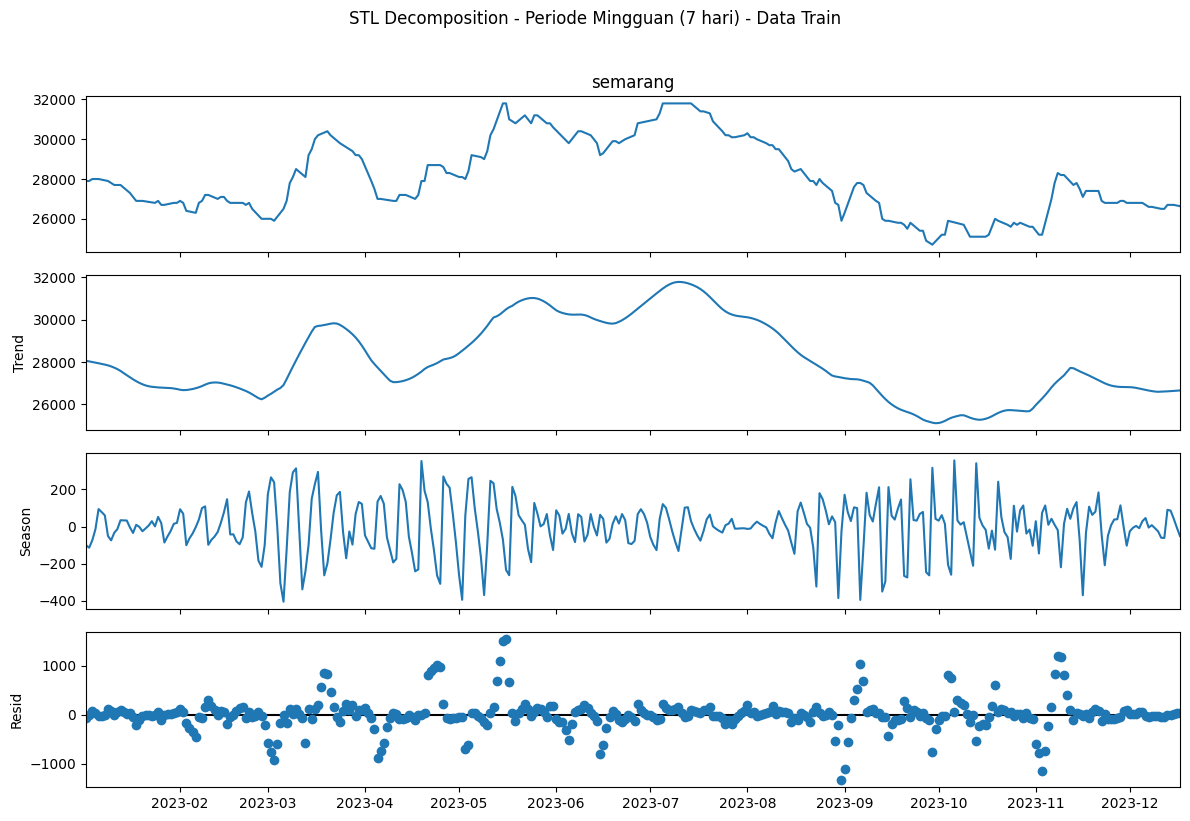

In [ ]:
# Decomposition visual - periode mingguan (paling umum untuk harga pangan harian)
# Dihitung pada data TRAIN saja
stl_weekly = STL(train, period=7, robust=True).fit()
fig = stl_weekly.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL Decomposition - Periode Mingguan (7 hari) - Data Train", y=1.02)
plt.tight_layout()
plt.show()


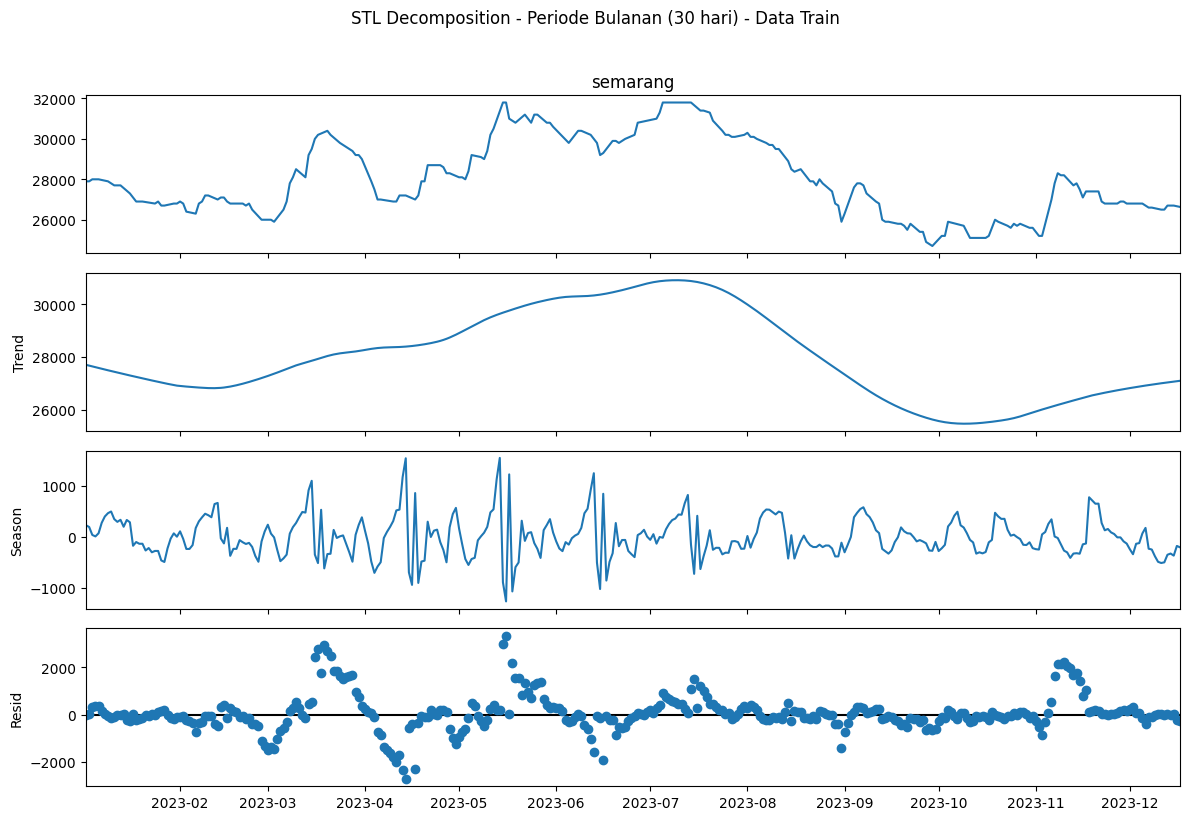

In [ ]:
# Decomposition visual - periode bulanan (untuk lihat pola bulanan yang lebih lebar)
# Dihitung pada data TRAIN saja
stl_monthly = STL(train, period=30, robust=True).fit()
fig = stl_monthly.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL Decomposition - Periode Bulanan (30 hari) - Data Train", y=1.02)
plt.tight_layout()
plt.show()


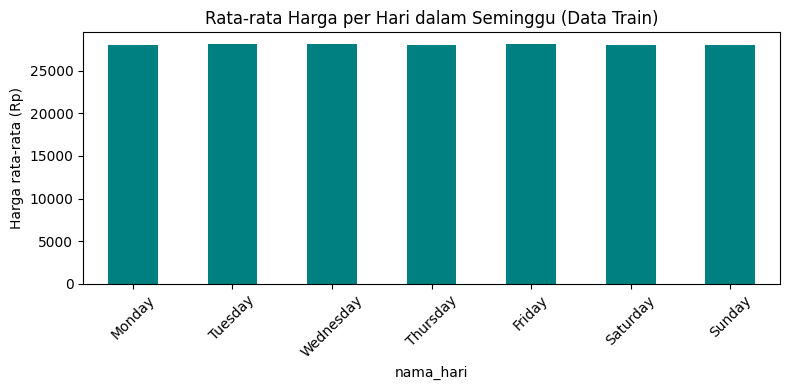

nama_hari
Monday       28058.500000
Tuesday      28088.000000
Wednesday    28074.500000
Thursday     28060.750000
Friday       28081.500000
Saturday     28065.166667
Sunday       28048.833333
Name: semarang, dtype: float64


In [ ]:
# Cek tambahan: pola rata-rata harga per hari dalam seminggu (pada Data Train)
df_hari = train.to_frame(name="semarang")
df_hari["nama_hari"] = df_hari.index.day_name()
urutan_hari = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
rata_per_hari = df_hari.groupby("nama_hari")["semarang"].mean().reindex(urutan_hari)

plt.figure(figsize=(8, 4))
rata_per_hari.plot(kind="bar", color="teal")
plt.title("Rata-rata Harga per Hari dalam Seminggu (Data Train)")
plt.ylabel("Harga rata-rata (Rp)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(rata_per_hari)


**Cara membaca hasil di atas:**
- Nilai *kekuatan musiman* mendekati **0** → hampir tidak ada pola musiman, pergerakan harga lebih didominasi tren/random walk.
- Nilai **> 0.3–0.4** biasanya sudah dianggap indikasi musiman yang cukup jelas.
- Panel *seasonal* pada plot STL akan terlihat sebagai pola berulang yang rapi jika memang ada musiman; kalau terlihat acak/tidak berpola, berarti musiman lemah.
- Jika ternyata **ada** musiman yang jelas (mingguan atau bulanan), sebaiknya pakai **SARIMA** (bukan ARIMA biasa) supaya pola musiman ikut ditangkap model — lihat Bagian 6 di bawah.

## 5. Differencing (jika data belum stasioner) — pada Data Train

In [ ]:
d = 0
series_diff = train.copy()
p_value = p_value_awal
while p_value > 0.05 and d < 2:
    series_diff = series_diff.diff().dropna()
    d += 1
    p_value = uji_adf(series_diff, f"Differencing ke-{d} (Data Train)")

print(f"\nOrder differencing (d) yang dipakai: d = {d}")



--- ADF Test: Differencing ke-1 (Data Train) ---
ADF Statistic : -8.83815119542162
p-value       : 1.6968835196214295e-14
=> Data STASIONER (tolak H0)

Order differencing (d) yang dipakai: d = 1


/tmp/ipykernel_1853/1262130798.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  hasil = adfuller(series.dropna())


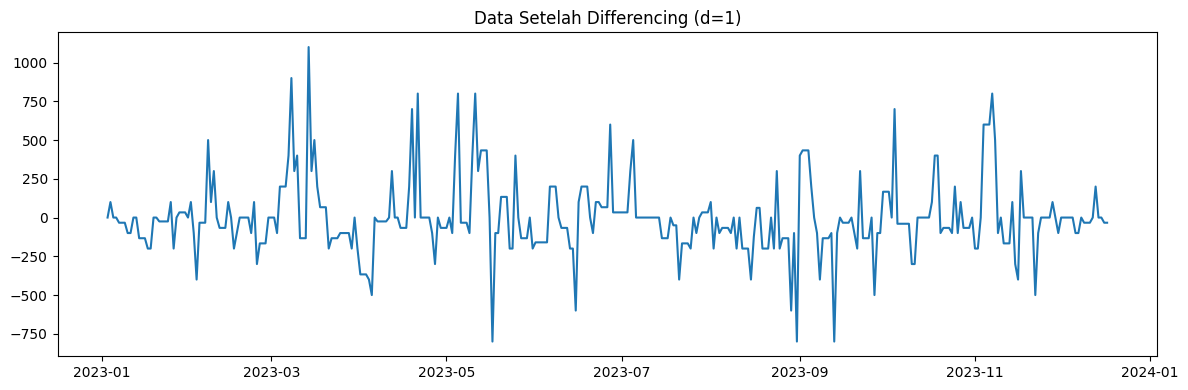

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(series_diff)
plt.title(f"Data Setelah Differencing (d={d})")
plt.tight_layout()
plt.show()

## 6. Identifikasi Order (p, d, q) -> ACF & PACF, serta `auto_arima` — pada Data Train

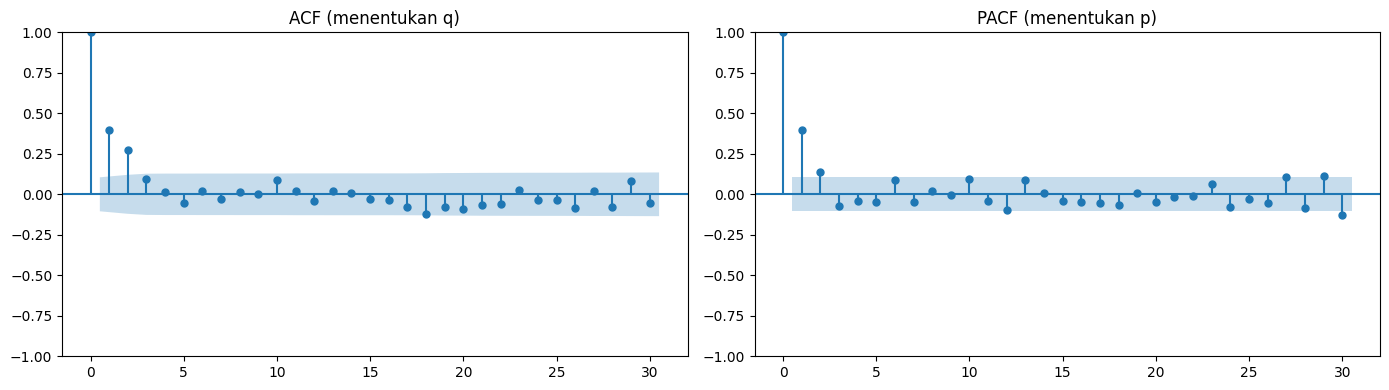

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_diff, ax=axes[0], lags=30)
plot_pacf(series_diff, ax=axes[1], lags=30, method="ywm")
axes[0].set_title("ACF (menentukan q)")
axes[1].set_title("PACF (menentukan p)")
plt.tight_layout()
plt.show()

# Perhatikan juga lag musiman (7, 14, 21, ...) pada ACF di atas:
# jika muncul lonjakan signifikan tepat di lag kelipatan 7, itu penguat lain
# bahwa ada pola musiman mingguan.

In [ ]:
# (Opsional tapi direkomendasikan) cari order otomatis dengan pmdarima
# -> sekarang dicoba dua versi: non-musiman (ARIMA) dan musiman (SARIMA, m=7)
# PENTING (prinsip ADW / anti data-leakage): auto_arima dijalankan HANYA pada
# data TRAIN, bukan seluruh df. Kalau seluruh data (termasuk test) dipakai di
# sini, pemilihan order model jadi "mengintip" data test sehingga evaluasi di
# Bagian 8 tidak lagi objektif.
try:
    import pmdarima as pm
except ImportError:
    import sys
    !{sys.executable} -m pip install pmdarima -q
    import pmdarima as pm

# Versi non-musiman
auto_model = pm.auto_arima(
    train,
    start_p=0, start_q=0, max_p=5, max_q=5, d=None,
    seasonal=False, trace=True,
    error_action="ignore", suppress_warnings=True, stepwise=True,
)
order_terbaik = auto_model.order
print("\nOrder (p,d,q) non-musiman terbaik:", order_terbaik, "| AIC =", auto_model.aic())

# Versi musiman (mingguan, m=7) -> hanya masuk akal kalau kekuatan musiman di Bagian 4 cukup tinggi
auto_model_seasonal = pm.auto_arima(
    train,
    start_p=0, start_q=0, max_p=3, max_q=3, d=None,
    start_P=0, start_Q=0, max_P=2, max_Q=2, D=None,
    seasonal=True, m=7, trace=True,
    error_action="ignore", suppress_warnings=True, stepwise=True,
)
order_seasonal = auto_model_seasonal.order
seasonal_order_terbaik = auto_model_seasonal.seasonal_order
print("\nOrder (p,d,q)(P,D,Q,m) musiman terbaik:", order_seasonal, seasonal_order_terbaik,
      "| AIC =", auto_model_seasonal.aic())

if auto_model_seasonal.aic() < auto_model.aic():
    print("\n=> Model MUSIMAN (SARIMA) punya AIC lebih rendah -> pola musiman terkonfirmasi bermanfaat untuk model.")
    PAKAI_SARIMA = True
else:
    print("\n=> Model non-musiman (ARIMA) sudah cukup / lebih baik -> komponen musiman tidak signifikan untuk model.")
    PAKAI_SARIMA = False


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 12.5 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4811.613, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4759.010, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4774.581, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4809.695, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=4753.820, Time=0.11 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=4754.196, Time=0.17 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=4754.367, Time=0.41 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4756.213, Time=0.12 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=4755.375, Time=0.69 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=4751.943, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=4757.117, Time=0.03 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=4752.314, Time=0.07 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=4752.476, Time=0.27 sec
 ARIMA(1,1,1)(0,0,

## 7. Fit Model pada Data Train (ARIMA atau SARIMA, otomatis sesuai hasil Bagian 6)

In [ ]:
if PAKAI_SARIMA:
    model = SARIMAX(train, order=order_seasonal, seasonal_order=seasonal_order_terbaik,
                     enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    order_terbaik = order_seasonal  # dipakai lagi di bagian bawah untuk judul plot
else:
    model = ARIMA(train, order=order_terbaik)
    model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               semarang   No. Observations:                  350
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -2372.972
Date:                Mon, 14 Sep 2026   AIC                           4751.943
Time:                        16:28:42   BIC                           4763.509
Sample:                    01-02-2023   HQIC                          4756.547
                         - 12-17-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3022      0.036      8.431      0.000       0.232       0.372
ar.L2          0.1348      0.041      3.281      0.001       0.054       0.215
sigma2      4.664e+04   1934.689     24.108      0.0

## 8. Evaluasi Model pada Data Test

In [ ]:
forecast_test = model_fit.forecast(steps=n_test)
forecast_test.index = test.index

mae = mean_absolute_error(test, forecast_test)
rmse = np.sqrt(mean_squared_error(test, forecast_test))
mape = np.mean(np.abs((test - forecast_test) / test)) * 100

print("--- Evaluasi Model pada Data Test ---")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:,.2f}%")

--- Evaluasi Model pada Data Test ---
MAE  : 526.86
RMSE : 1,149.89
MAPE : 2.19%


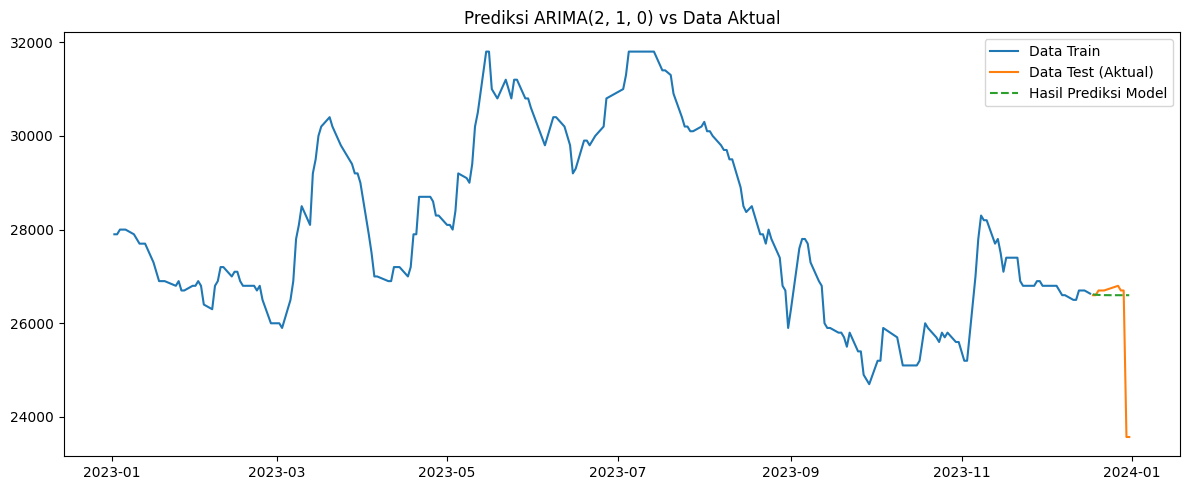

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Data Train")
plt.plot(test.index, test, label="Data Test (Aktual)")
plt.plot(forecast_test.index, forecast_test, label="Hasil Prediksi Model", linestyle="--")
plt.title(f"Prediksi {'SARIMA' if PAKAI_SARIMA else 'ARIMA'}{order_terbaik} vs Data Aktual")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Diagnostik Residual Model

In [ ]:
residual = model_fit.resid
lb_test = acorr_ljungbox(residual, lags=[10], return_df=True)
print("--- Uji Ljung-Box pada Residual ---")
print(lb_test)
print("p-value > 0.05 berarti residual bersifat white noise (model sudah cukup baik).")

--- Uji Ljung-Box pada Residual ---
     lb_stat  lb_pvalue
10  0.112068        1.0
p-value > 0.05 berarti residual bersifat white noise (model sudah cukup baik).


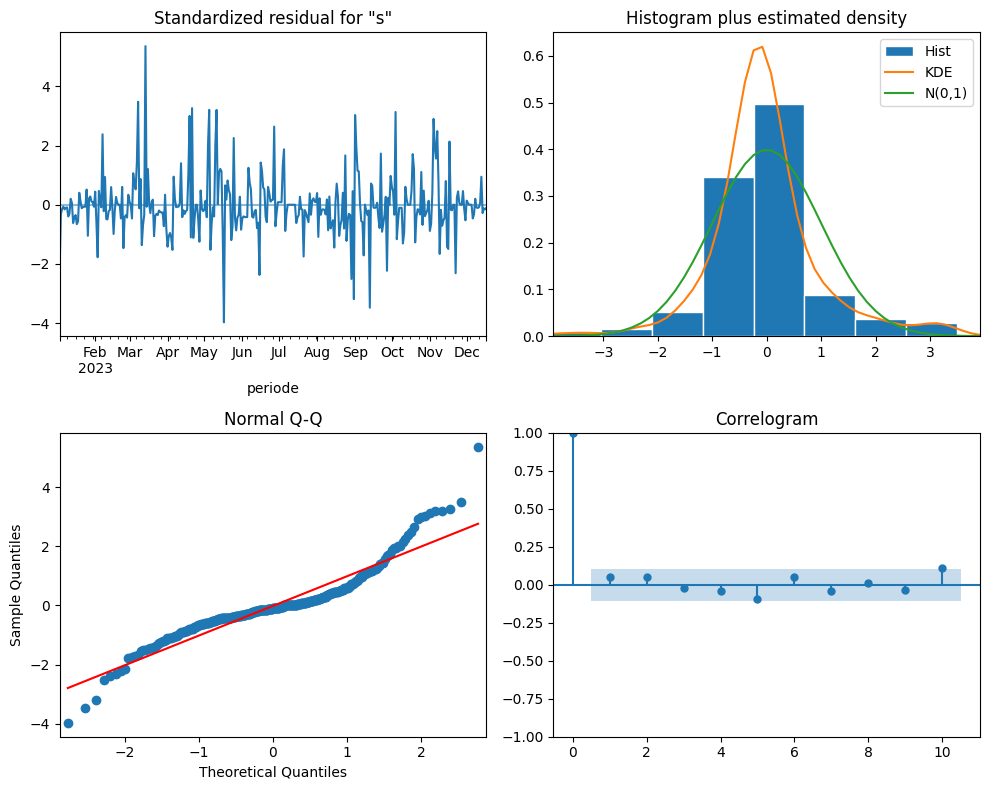

In [ ]:
model_fit.plot_diagnostics(figsize=(10, 8))
plt.tight_layout()
plt.show()

## 10. Forecast / Peramalan ke Depan

Setelah model tervalidasi bagus di tahap 8, refit model dengan **seluruh data** (train+test) agar peramalan ke depan lebih akurat.

In [ ]:
n_forecast = 14   # ramalkan 14 hari ke depan

if PAKAI_SARIMA:
    final_model = SARIMAX(df["semarang"], order=order_seasonal, seasonal_order=seasonal_order_terbaik,
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
else:
    final_model = ARIMA(df["semarang"], order=order_terbaik).fit()

forecast_result = final_model.get_forecast(steps=n_forecast)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

hasil_forecast = pd.DataFrame({
    "forecast": forecast_mean,
    "lower_ci": conf_int.iloc[:, 0],
    "upper_ci": conf_int.iloc[:, 1],
})
print(f"--- Hasil Peramalan {n_forecast} Hari ke Depan ---")
hasil_forecast

--- Hasil Peramalan 14 Hari ke Depan ---


,forecast,lower_ci,upper_ci
2024-01-01,23011.019230,22479.082724,23542.955736
2024-01-02,22910.079057,22087.348050,23732.810063
2024-01-03,22791.283345,21684.538308,23898.028382
2024-01-04,22751.805041,21399.141117,24104.468965
2024-01-05,22723.394172,21149.501771,24297.286572
2024-01-06,22711.201536,20938.262874,24484.140199
2024-01-07,22703.911910,20749.221279,24658.602540
2024-01-08,22700.413439,20578.199791,24822.627088
2024-01-09,22698.476491,20420.362186,24976.590796
2024-01-10,22697.500494,20273.175327,25121.825661


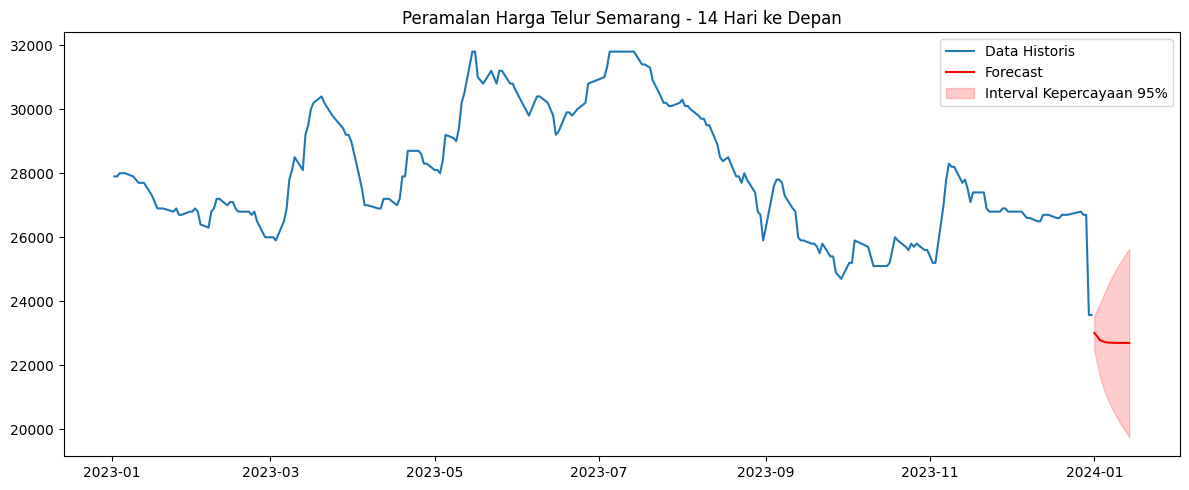

Selesai. Hasil forecast (.xlsx) sudah tersimpan di folder yang sama.


In [ ]:
hasil_forecast.to_excel("hasil_forecast_harga_telur.xlsx")

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["semarang"], label="Data Historis")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", color="red")
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                  color="red", alpha=0.2, label="Interval Kepercayaan 95%")
plt.title(f"Peramalan Harga Telur Semarang - {n_forecast} Hari ke Depan")
plt.legend()
plt.tight_layout()
plt.show()

print("Selesai. Hasil forecast (.xlsx) sudah tersimpan di folder yang sama.")